In [1]:
%load_ext autoreload
%autoreload 2

from mGST.visualization import visualize_data_sets_as_bars

In [48]:
def time_to_seconds(days: int = 0, hours: int = 0, minutes: int = 0, seconds: int = 0) -> float:
    """Convert time duration to seconds."""
    return days * 24 * 3600 + hours * 3600 + minutes * 60 + seconds

def format_time(days:float = 0, hours:float = 0, minutes:float = 0, seconds: float = 0) -> str:
    """Format time in seconds to a human-readable string."""
    total_seconds = time_to_seconds(days, hours, minutes, seconds)
    days, total_seconds = divmod(total_seconds, 24 * 3600)
    hours, total_seconds = divmod(total_seconds, 3600)
    minutes, total_seconds = divmod(total_seconds, 60)
    return f"{int(days)}d {int(hours)}h {int(minutes)}m {total_seconds:.1f}s"

In [49]:
# Time for 4Q
format_time(minutes=215, seconds=11.2)

'0d 3h 35m 11.2s'

In [50]:
times_mgst = [time_to_seconds(minutes=8, seconds=8),
             time_to_seconds(minutes=39, seconds=50),
            #  time_to_seconds(hours=2, minutes=26, seconds=10),
             time_to_seconds(hours=9, minutes=1, seconds=43),
             time_to_seconds(days=3, hours=2),
             0,
             0,
             ]

times_this_work = [time_to_seconds(minutes=12, seconds=55.5),
            time_to_seconds(minutes=11, seconds=37.8),
            # 0,
            time_to_seconds(minutes=12, seconds=1.8),
            time_to_seconds(minutes=25, seconds=29.7),
            time_to_seconds(minutes=30, seconds=51.0),
            time_to_seconds(minutes=215, seconds=11.2),
            ]


x_labels = [r"$r_k = 1$" + "\n 2Q",
            r"$r_k = 4$" + "\n 2Q",
            # r"2Q $r_k = 8$",
            r"$r_k = 16$" + "\n 2Q",
            r"$r_k = 1$" + "\n 3Q",
            r"$r_k = 4$" + "\n 3Q",
            r"$r_k = 1$" + "\n 4Q",
            ]

bar_labels = ["Brieger et.al", "This work"]
data_sets = {label: {bar_labels[0]: time_mgst, bar_labels[1]: time_mps} for label, time_mgst, time_mps in zip(x_labels, times_mgst, times_this_work)}
data_sets

{'$r_k = 1$\n 2Q': {'Brieger et.al': 488, 'This work': 775.5},
 '$r_k = 4$\n 2Q': {'Brieger et.al': 2390, 'This work': 697.8},
 '$r_k = 16$\n 2Q': {'Brieger et.al': 32503, 'This work': 721.8},
 '$r_k = 1$\n 3Q': {'Brieger et.al': 266400, 'This work': 1529.7},
 '$r_k = 4$\n 3Q': {'Brieger et.al': 0, 'This work': 1851.0},
 '$r_k = 1$\n 4Q': {'Brieger et.al': 0, 'This work': 12911.2}}

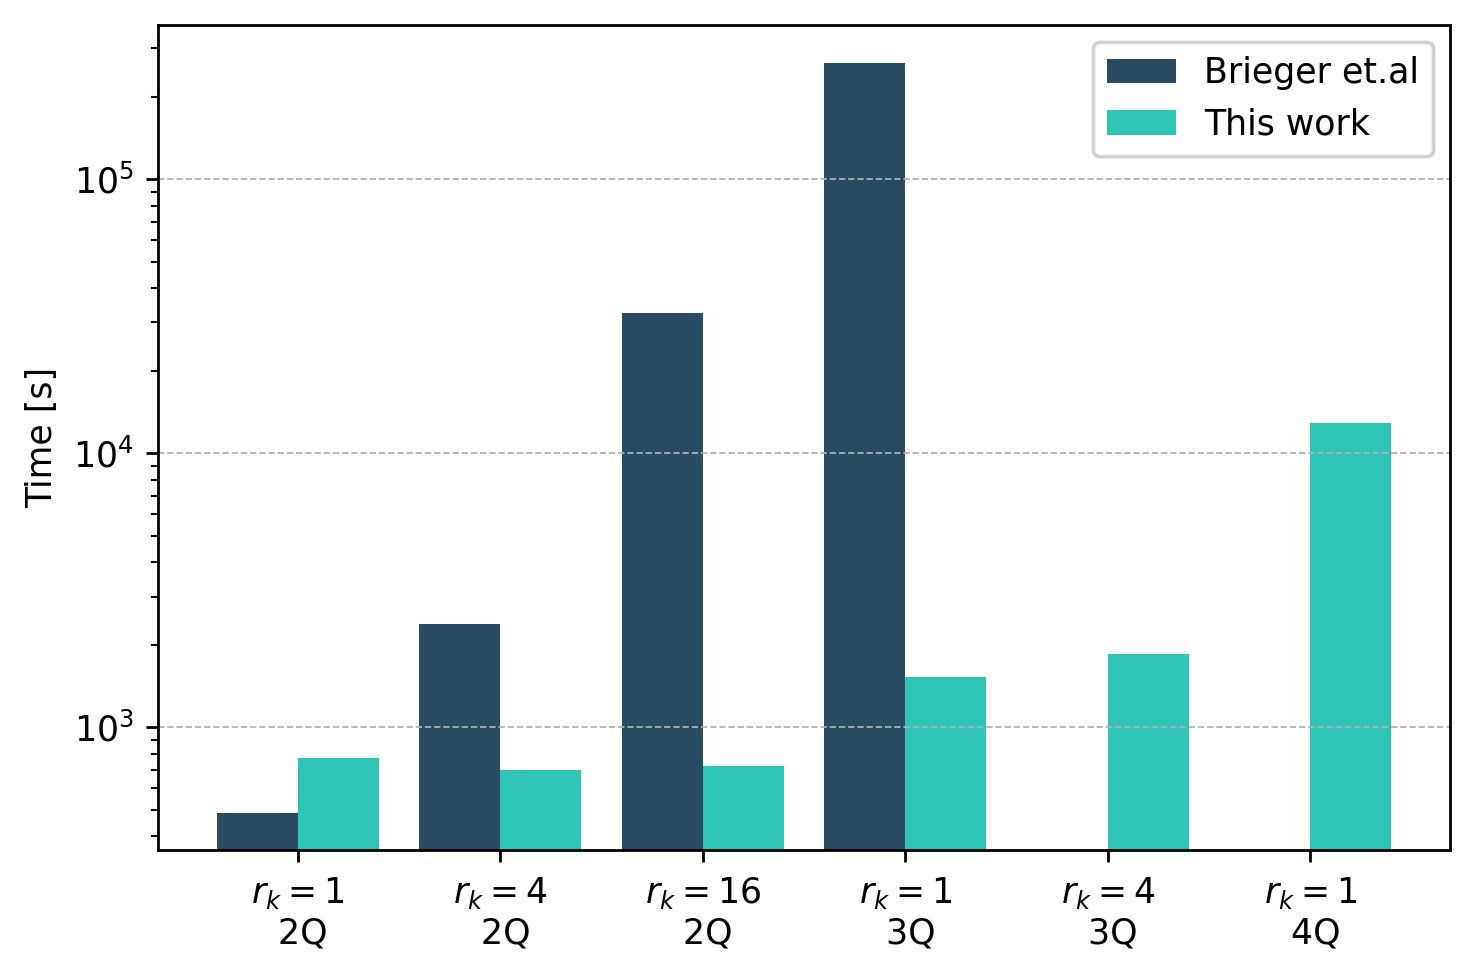

In [45]:
fig = visualize_data_sets_as_bars(
    data=data_sets,
    bar_labels=bar_labels,
    title=None,
    logscale=True,
)

In [46]:
fig.savefig("reconstruction_time_comparison.pdf", bbox_inches="tight", transparent=True)